In [9]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1)

#### Simulating Recognition Memory Data for SDT Model

In [3]:
# Defining the true psychological parameters.

true_d_prime = 1.5
true_criterion = 0.2

# Defining the experiment.

n_signal = 100
n_noise = 100

# Simulating internal evidence.

# New (unstudied) words.
noise_evidence = np.random.normal(
    loc=0,
    scale=1,
    size=n_noise
)

# Old (studied) words.
signal_evidence = np.random.normal(
    loc=true_d_prime,
    scale=1,
    size=n_signal
)

In [4]:
# Making decisions.

# Respond "Old" if evidence exceeds the criterion.

noise_response = noise_evidence > true_criterion
signal_response = signal_evidence > true_criterion

# Computing SDT outcomes.

hits = np.sum(signal_response)

misses = n_signal - hits

false_alarms = np.sum(noise_response)

correct_rejections = n_noise - false_alarms

# Computing rates.

hit_rate = hits / n_signal

false_alarm_rate = false_alarms / n_noise

In [6]:
# Displaying results.

print("True d': ", true_d_prime)
print("True criterion: ", true_criterion)

print("\nSignal trials: ", n_signal)
print("Noise trials: ", n_noise)

print("\nHits: ", hits)
print("Misses: ", misses)
print("False alarms: ", false_alarms)
print("Correct rejections: ", correct_rejections)

print("Hit rate: ", round(hit_rate, 3))
print("False alarm rate: ", round(false_alarm_rate, 3))

True d':  1.5
True criterion:  0.2

Signal trials:  100
Noise trials:  100

Hits:  93
Misses:  7
False alarms:  41
Correct rejections:  59
Hit rate:  0.93
False alarm rate:  0.41


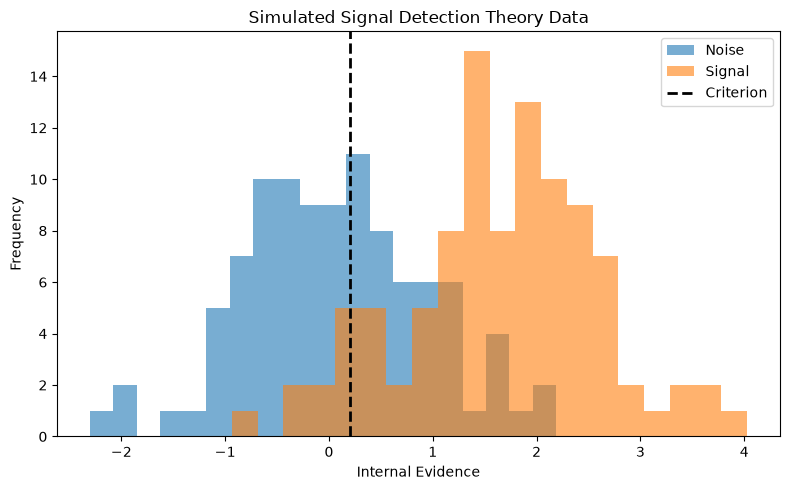

In [7]:
# Visualizing the evidence distributions.

plt.figure(figsize=(8, 5))

plt.hist(
    noise_evidence,
    bins=20,
    alpha=0.6,
    label="Noise"
)

plt.hist(
    signal_evidence,
    bins=20,
    alpha=0.6,
    label="Signal"
)

plt.axvline(
    true_criterion,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Criterion"
)

plt.title("Simulated Signal Detection Theory Data")
plt.xlabel("Internal Evidence")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()

plt.show()

#### Bayesian SDT Model

In [10]:
# Building the Bayesian Signal Detection Theory model.

with pm.Model() as sdt_model:

    # Prior distributions.
    d_prime = pm.Normal(
        "d_prime",
        mu=0,
        sigma=3
    )

    criterion = pm.Normal(
        "criterion",
        mu=0,
        sigma=3
    )

    # Hit and false alarm probabilities.
    hit_probability = pm.Deterministic(
        "hit_probability",
        pm.math.invprobit(d_prime - criterion)
    )

    false_alarm_probability = pm.Deterministic(
        "false_alarm_probability",
        pm.math.invprobit(-criterion)
    )

    # Likelihood.
    hits_observed = pm.Binomial(
        "hits",
        n=n_signal,
        p=hit_probability,
        observed=hits
    )

    false_alarms_observed = pm.Binomial(
        "false_alarms",
        n=n_noise,
        p=false_alarm_probability,
        observed=false_alarms
    )

    # Posterior sampling.
    trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [d_prime, criterion]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 21 seconds.


In [12]:
# Posterior Summary

summary = az.summary(
    trace,
    var_names=[
        "d_prime",
        "criterion"
    ],
    hdi_prob=0.95
)

print(summary)

            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
d_prime    1.713  0.226     1.267      2.159      0.004    0.003    4156.0   
criterion  0.227  0.126    -0.024      0.467      0.002    0.001    4188.0   

           ess_tail  r_hat  
d_prime      4583.0    1.0  
criterion    4811.0    1.0  


In [13]:
# Comparing Estimated and True Parameters.

print("True Parameters")
print("d':", true_d_prime)
print("Criterion:", true_criterion)

posterior = az.summary(
    trace,
    var_names=[
        "d_prime",
        "criterion"
    ],
    hdi_prob=0.95
)

print("\nEstimated Parameters")

print("\nd':")
print("Posterior mean:",
      round(posterior.loc["d_prime", "mean"], 3))
print("95% HDI: [",
      round(posterior.loc["d_prime", "hdi_2.5%"], 3),
      ",",
      round(posterior.loc["d_prime", "hdi_97.5%"], 3),
      "]")

print("\nCriterion:")
print("Posterior mean:",
      round(posterior.loc["criterion", "mean"], 3))
print("95% HDI: [",
      round(posterior.loc["criterion", "hdi_2.5%"], 3),
      ",",
      round(posterior.loc["criterion", "hdi_97.5%"], 3),
      "]")

True Parameters
d': 1.5
Criterion: 0.2

Estimated Parameters

d':
Posterior mean: 1.713
95% HDI: [ 1.267 , 2.159 ]

Criterion:
Posterior mean: 0.227
95% HDI: [ -0.024 , 0.467 ]


#### Interpret Psychological Parameters with Uncertainty

In [15]:
# Extracting posterior summary.

summary = az.summary(
    trace,
    var_names=["d_prime", "criterion"],
    hdi_prob=0.95
)

d_mean = summary.loc["d_prime", "mean"]
d_lower = summary.loc["d_prime", "hdi_2.5%"]
d_upper = summary.loc["d_prime", "hdi_97.5%"]

c_mean = summary.loc["criterion", "mean"]
c_lower = summary.loc["criterion", "hdi_2.5%"]
c_upper = summary.loc["criterion", "hdi_97.5%"]

# Displaying parameter estimates.

print("Sensitivity (d')")

print("Posterior mean:", round(d_mean, 3))
print("95% HDI: [", round(d_lower, 3), ",", round(d_upper, 3), "]")

print("\nDecision Criterion (c)")

print("Posterior mean:", round(c_mean, 3))
print("95% HDI: [", round(c_lower, 3), ",", round(c_upper, 3), "]")

Sensitivity (d')
Posterior mean: 1.713
95% HDI: [ 1.267 , 2.159 ]

Decision Criterion (c)
Posterior mean: 0.227
95% HDI: [ -0.024 , 0.467 ]


In [16]:
# Comparing with true values.

print("True d':", true_d_prime)
print("True criterion:", true_criterion)

True d': 1.5
True criterion: 0.2


In [17]:
# Psychological interpretation

# Sensitivity

if d_mean > 1.5:
    print("- The participant shows high sensitivity.")
elif d_mean > 0.75:
    print("- The participant shows moderate sensitivity.")
else:
    print("- The participant shows low sensitivity.")

# Criterion

if c_mean > 0.3:
    print("- The participant has a conservative response bias.")
elif c_mean < -0.3:
    print("- The participant has a liberal response bias.")
else:
    print("- The participant has little or no response bias.")

- The participant shows high sensitivity.
- The participant has little or no response bias.


Note: The credible intervals describe the plausible range of each psychological parameter given the observed responses and the Bayesian model.